## Note operative (kernel e ordine di esecuzione)

- Questo notebook e un orchestratore: la logica e nei moduli Python in `Mains/notebook_steps`.
- Se riapri il file o noti variabili residue, riavvia il kernel e poi esegui tutte le celle in ordine.
- Le spiegazioni estese sono in `Slides/Tavola_1.14_spiegazioni.md`.
- In caso di warning di inizializzazione su ARIMA (MA non invertibile), verifica convergenza e diagnostica residui prima di concludere.

# Tavola 1.14 - Notebook operativo

Dettagli testuali e interpretativi completi: `Slides/Tavola_1.14_spiegazioni.md`.

## Step 1 - Dataset

In [64]:
from pathlib import Path
import importlib

project_root = Path.cwd()
data_path = project_root / "Datasets" / "Tavola_1.14.csv"

required_modules = [
    "Mains.notebook_steps.step1_dataset",
    "Mains.notebook_steps.step2_preprocessing",
    "Mains.notebook_steps.step3_split",
    "Mains.notebook_steps.step4_statistical",
]

key_packages = ["pandas", "statsmodels", "sklearn", "matplotlib", "numpy"]

missing_modules = []
for mod in required_modules:
    try:
        importlib.import_module(mod)
    except Exception as exc:
        missing_modules.append((mod, str(exc)))

package_versions = {}
for pkg in key_packages:
    try:
        package_versions[pkg] = importlib.import_module(pkg).__version__
    except Exception as exc:
        package_versions[pkg] = f"ERROR: {exc}"

print("[sanity] cwd:", project_root)
print("[sanity] dataset exists:", data_path.exists(), "->", data_path)
if missing_modules:
    print("[sanity] module import issues:")
    for mod, err in missing_modules:
        print(f"  - {mod}: {err}")
else:
    print("[sanity] modules ok")

print("[sanity] key package versions:")
for pkg, version in package_versions.items():
    print(f"  - {pkg}: {version}")

[sanity] cwd: c:\Users\giann\Documents\GitHub\FinalProject
[sanity] dataset exists: True -> c:\Users\giann\Documents\GitHub\FinalProject\Datasets\Tavola_1.14.csv
[sanity] modules ok
[sanity] key package versions:
  - pandas: 3.0.1
  - statsmodels: 0.14.6
  - sklearn: 1.8.0
  - matplotlib: 3.10.8
  - numpy: 2.4.2


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("Datasets") / "Tavola_1.14.csv"
TARGET_COL = "Produzione_lorda_totale"

In [52]:
raw_preview, series_df, summary = load_istat_series(
    DATA_PATH,
    target_col_name=TARGET_COL,
)
raw_preview.head(8)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,ANNI,Produzione lorda (a),NaN,NaN,NaN,Consumo,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Totale,Di cui,NaN,NaN,Agricol-tura,Industria,NaN,Trasporti,Illumina-\nzione pubblica,"Commercio, servizi, pubblica ammi...",Usi domestici,Totale
2,NaN,NaN,Termo-elettrica tradizio-\nnale (b),Geo- termo-elettrica,NaN,NaN,Totale,di cui Manufat-turiera,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1883,1,....,-,NaN,....,....,....,....,....,....,....,....
5,1884,2,....,-,NaN,....,....,....,....,....,....,....,....
6,1885,3,....,-,NaN,....,....,....,....,....,....,....,....
7,1886,3,....,-,NaN,....,....,....,....,....,....,....,....


In [ ]:
series_df.head()

,Produzione_lorda_totale
Anno,
1883,1.0
1884,2.0
1885,3.0
1886,3.0
1887,4.0


In [ ]:
summary

,value
count,132.0
mean,89862.825758
std,107574.541777
min,1.0
25%,3300.0
50%,21738.0
75%,182721.75
max,319130.0
missing_values,0.0
start_year,1883.0


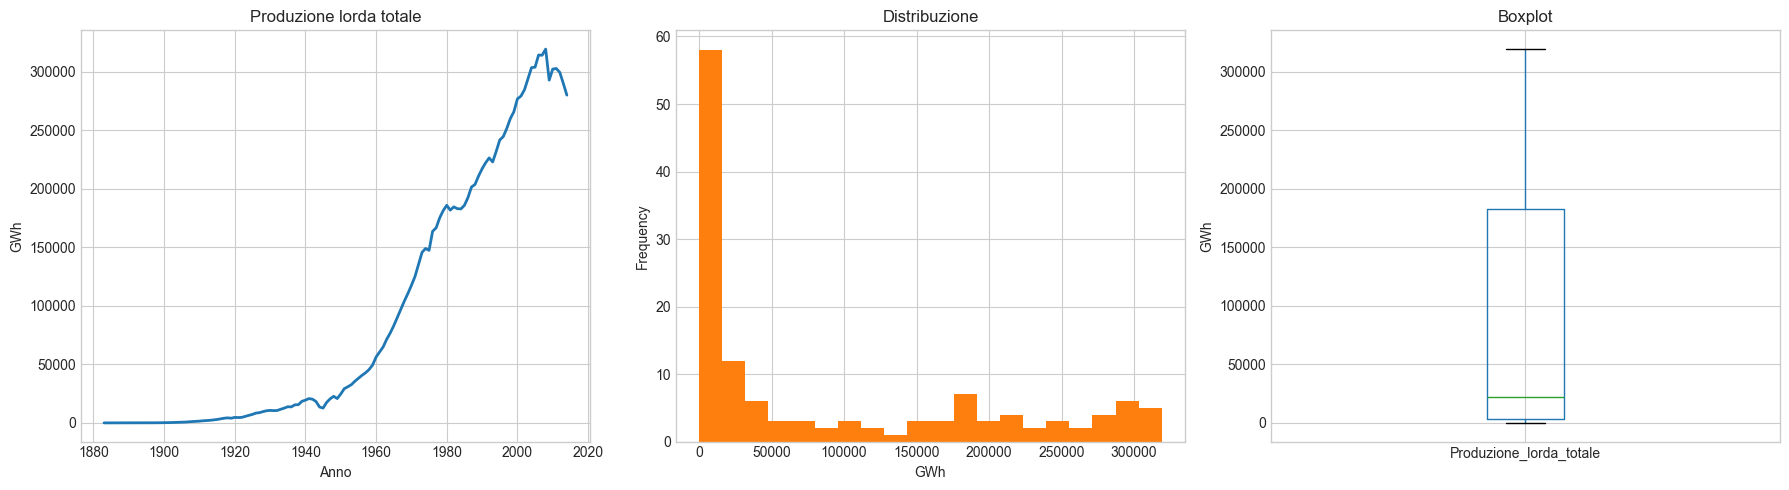

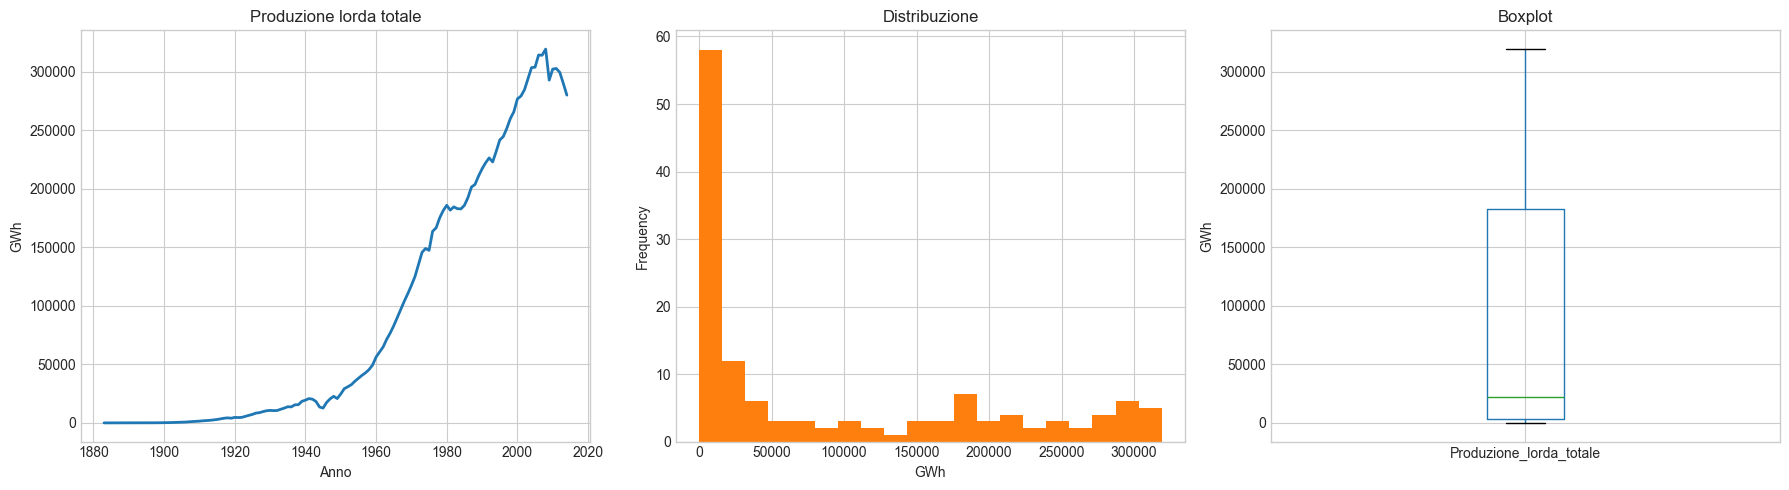

In [53]:
fig_step1 = plot_step1_overview(series_df, TARGET_COL)
fig_step1

Commento rapido: verificare trend, scala e asimmetria della distribuzione.

Nota: interpretazione estesa nello stesso file di spiegazioni esterno.

## Step 2 - Preprocessing

In [54]:
target_series, candidate_series, adf_results = run_step2_analysis(
    series_df,
    TARGET_COL,
)

In [ ]:
adf_results

,adf_stat,pvalue,stationary_at_5pct
series,,,
level,-1.459970,5.532128e-01,False
log,-4.759796,6.488138e-05,True
diff_1,-1.906669,3.289303e-01,False
log_diff_1,-2.681483,7.729769e-02,False
diff_2,-8.871223,1.396268e-14,True


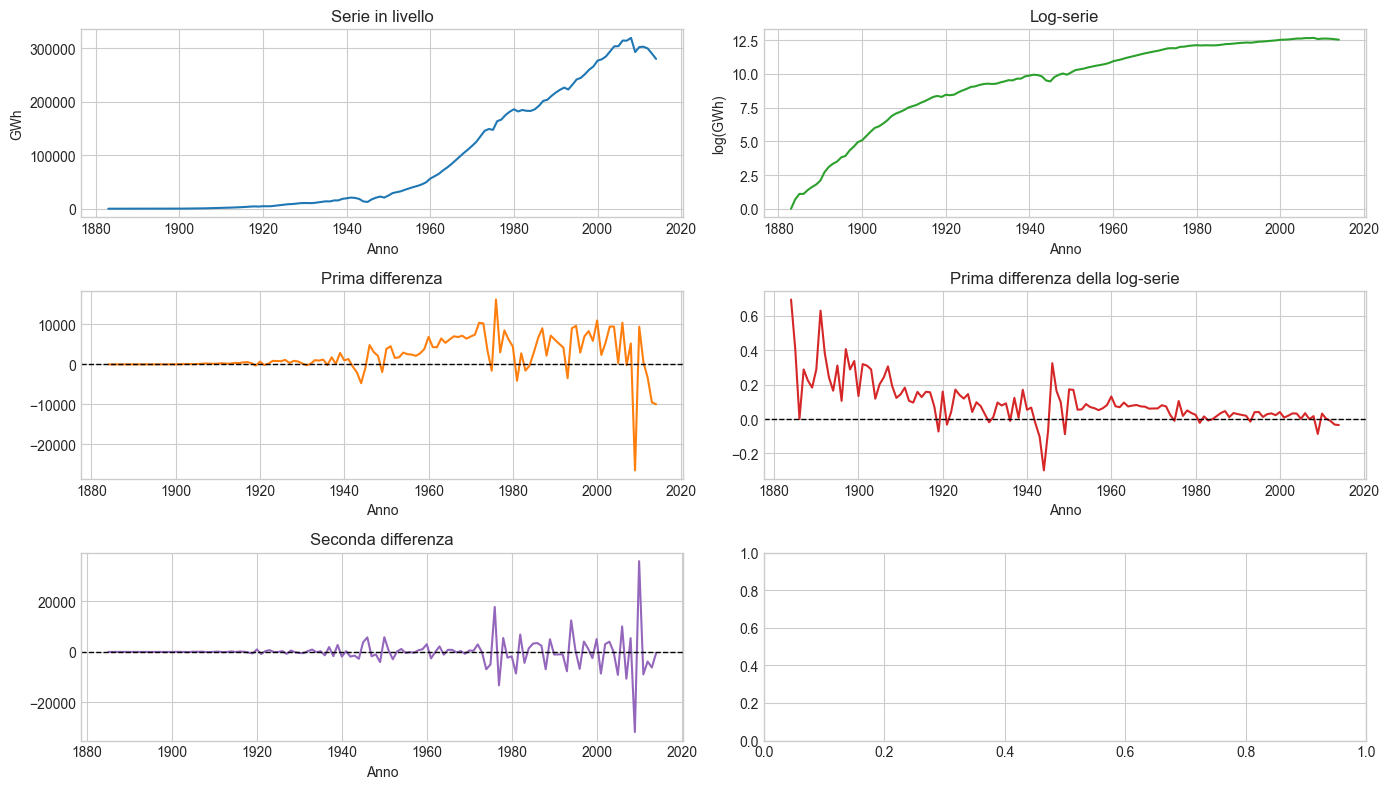

In [ ]:
fig_step2_transforms = plot_step2_transforms(candidate_series)
fig_step2_transforms

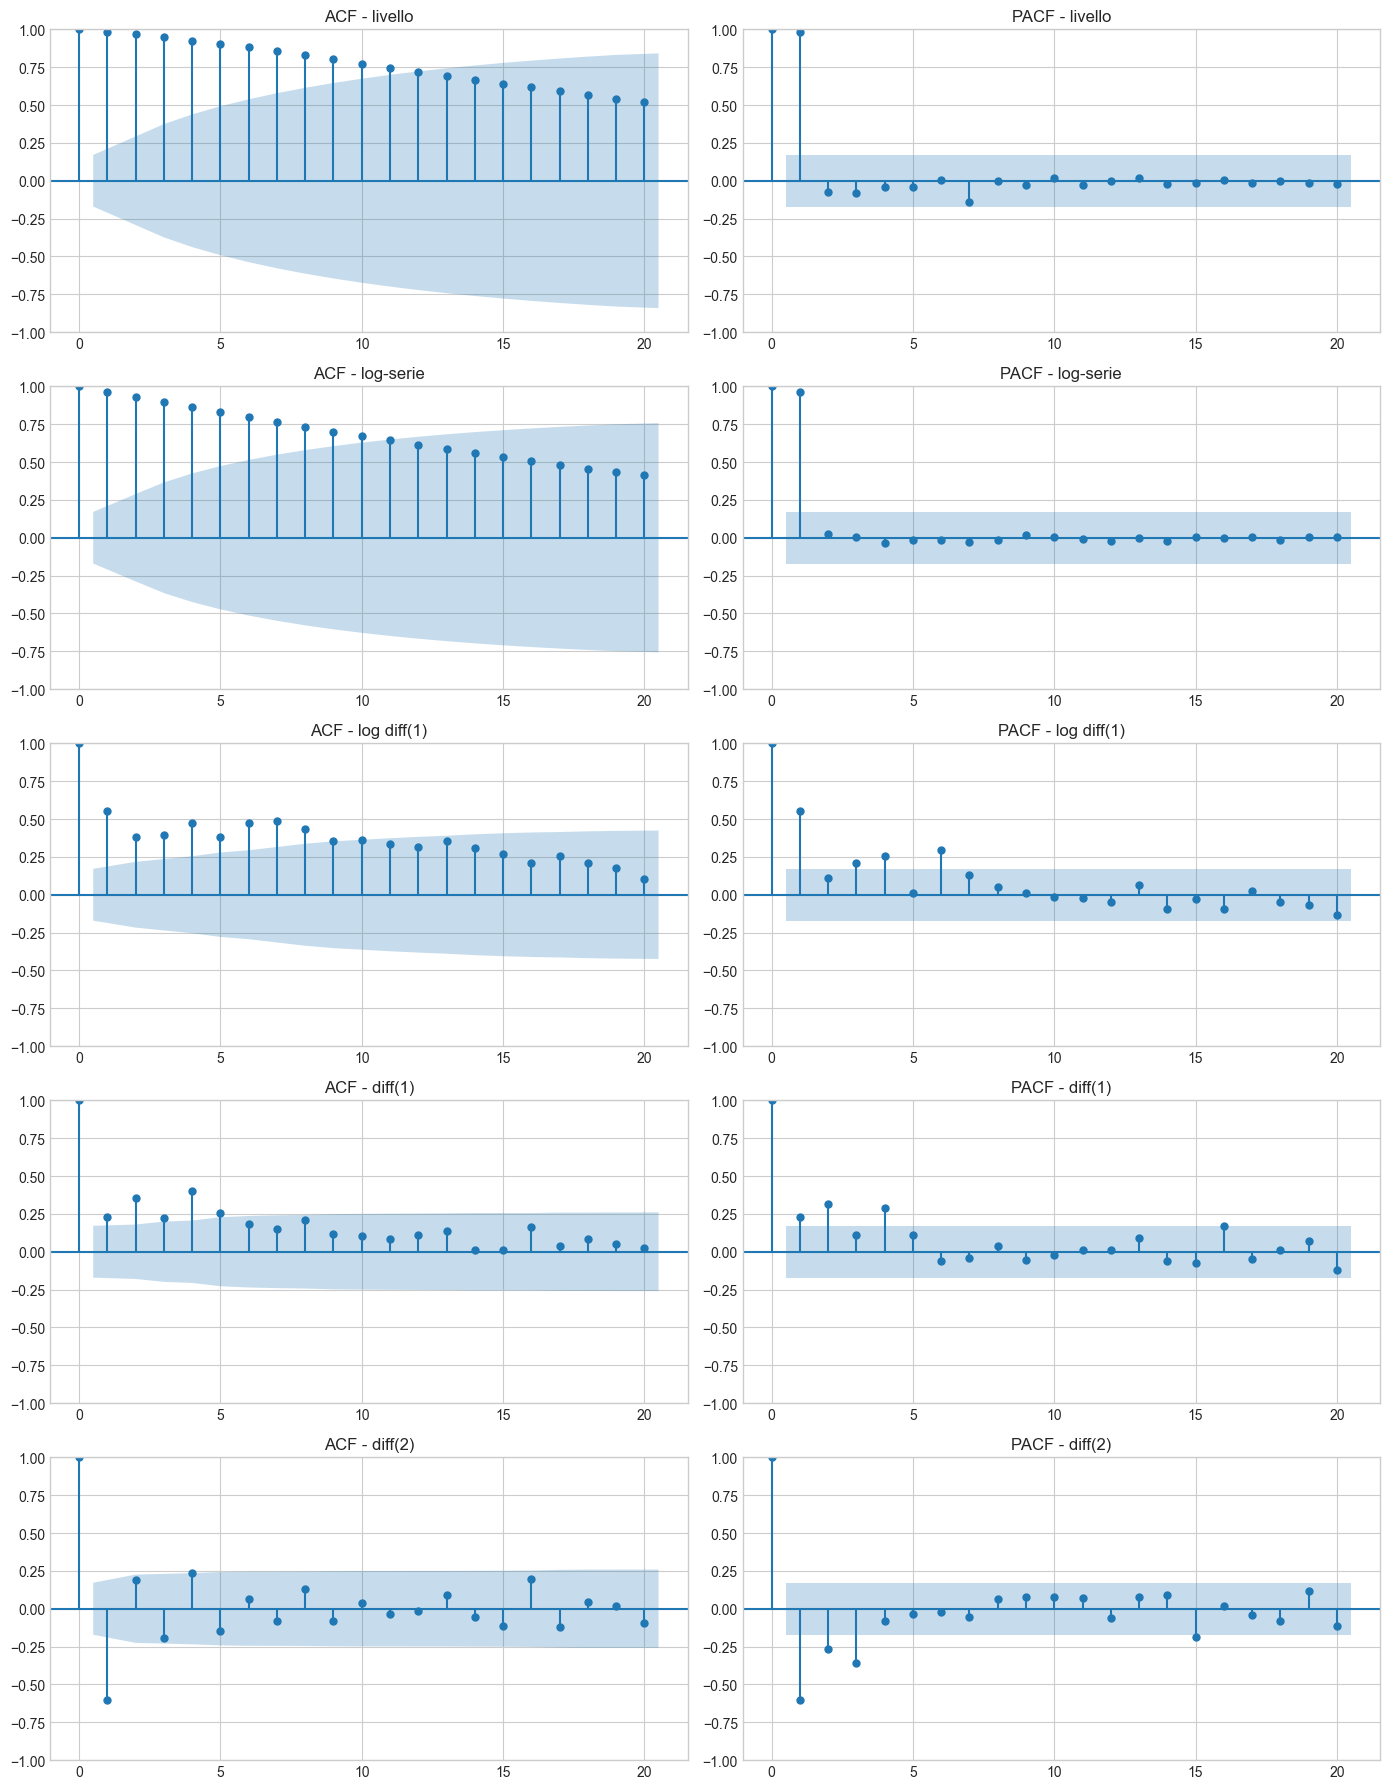

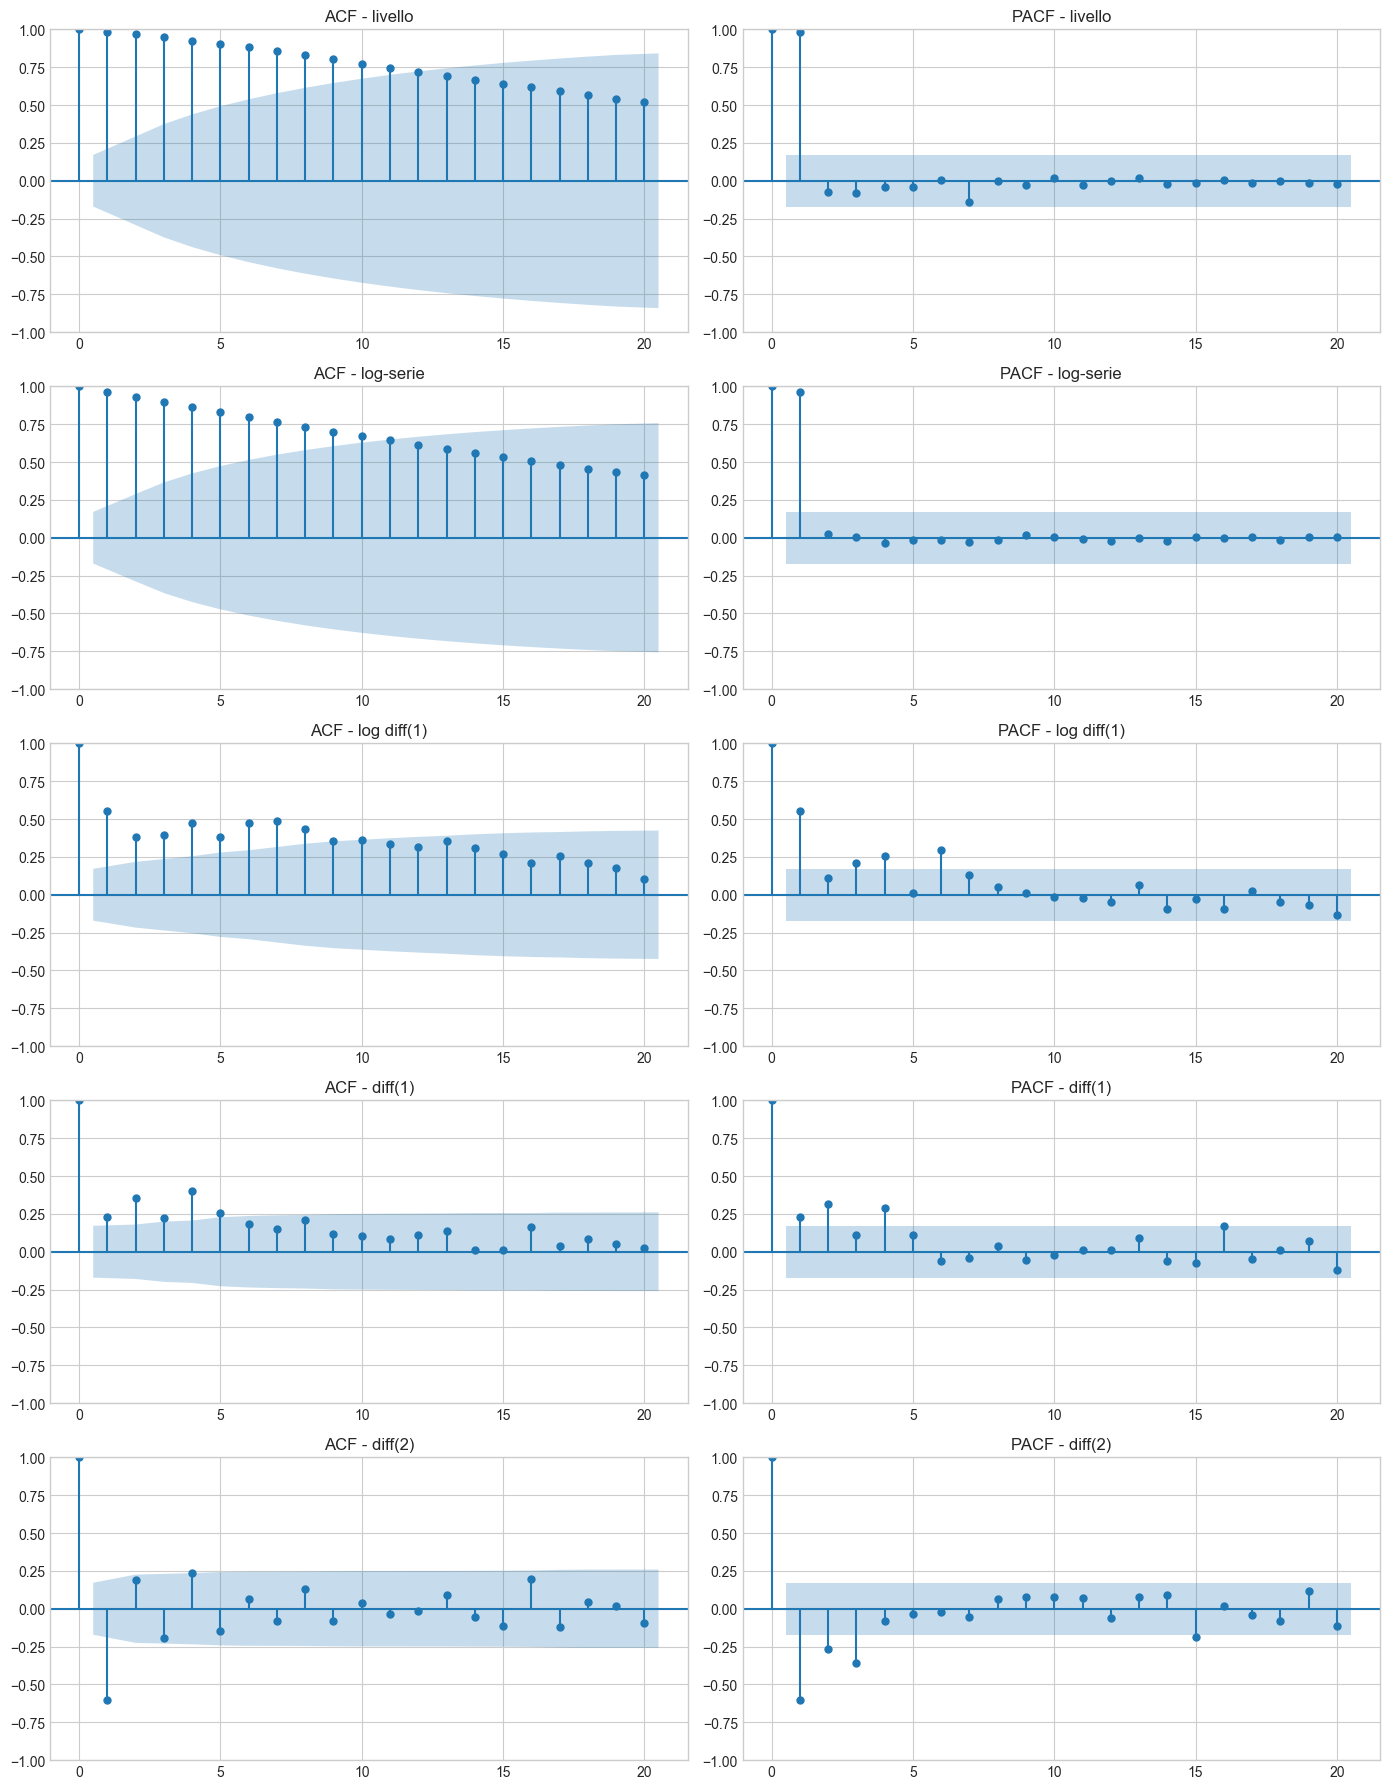

In [55]:
fig_step2_acf_pacf = plot_step2_acf_pacf_grid(candidate_series, lags=20)
fig_step2_acf_pacf

### Focus diff(2)

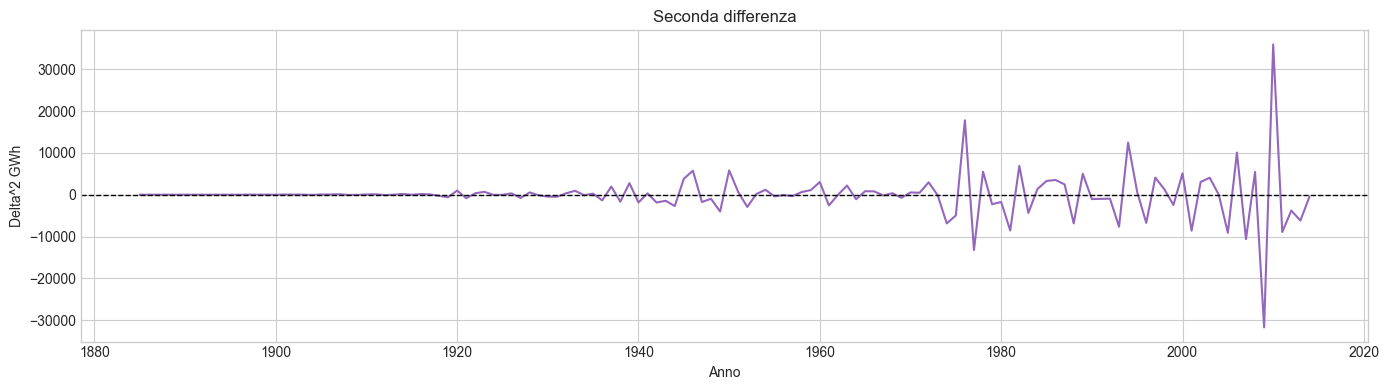

In [ ]:
fig_diff2_line, fig_diff2_acf_pacf = plot_diff2_focus(candidate_series, lags=20)
fig_diff2_line

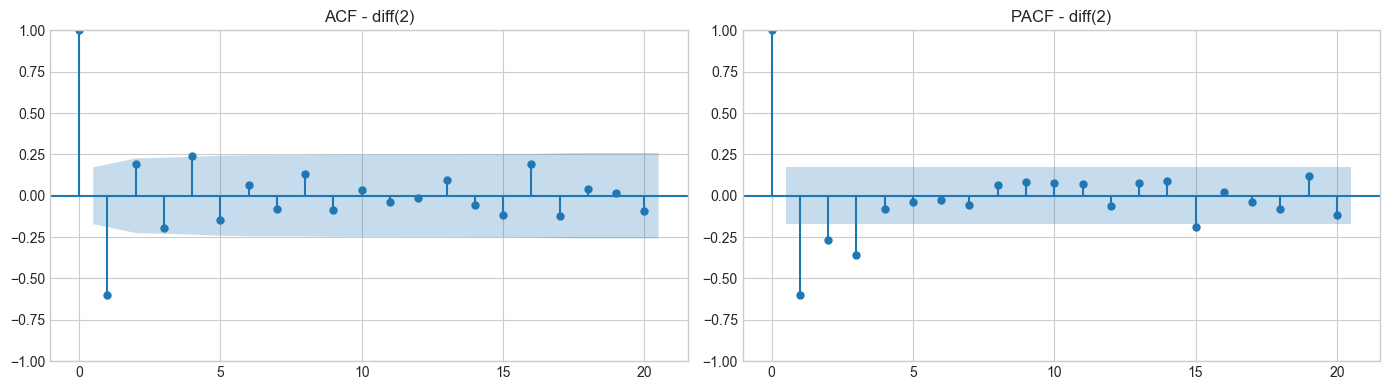

In [ ]:
fig_diff2_acf_pacf

Nota: usare ACF/PACF di diff(2) anche per controllare over-differencing.

Commento operativo Step 2: incrociare ADF, ACF/PACF e stabilita dei residui.

Sintesi rapida Step 2: candidati principali log_d0 e level_d2.

Nota: dettagli metodologici completi nel file esterno di spiegazioni.

## Step 3 - Split temporale

In [56]:
train_series, val_series, test_series, split_summary = temporal_split(
    target_series,
    train_ratio=0.8,
    val_ratio=0.1,
)
split_summary

,subset,n_obs,start_year,end_year
0,train,105,1883,1987
1,validation,13,1988,2000
2,test,14,2001,2014


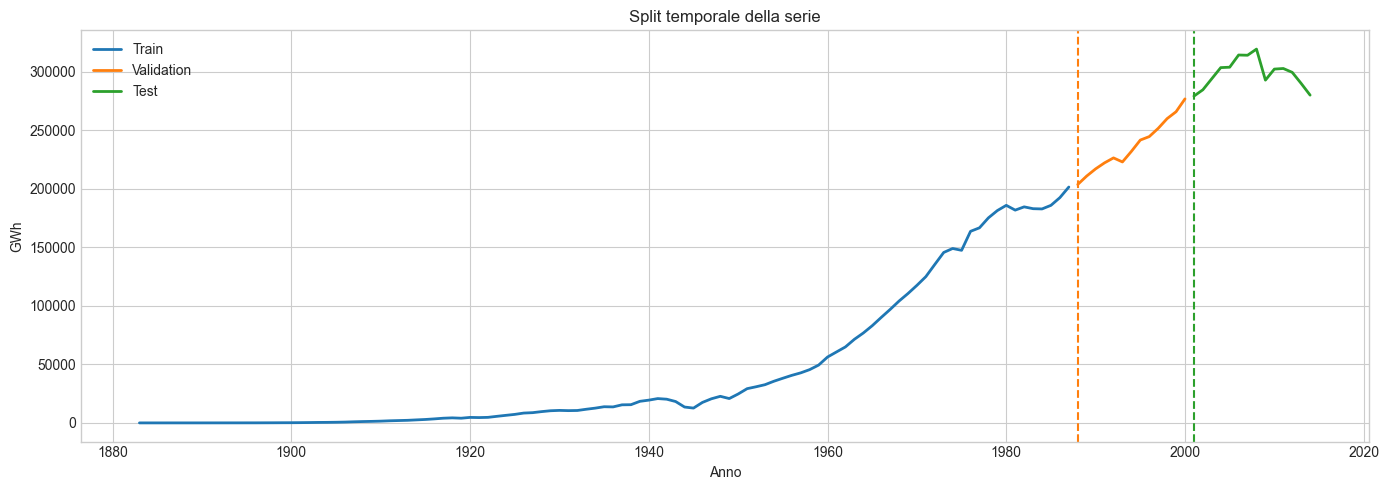

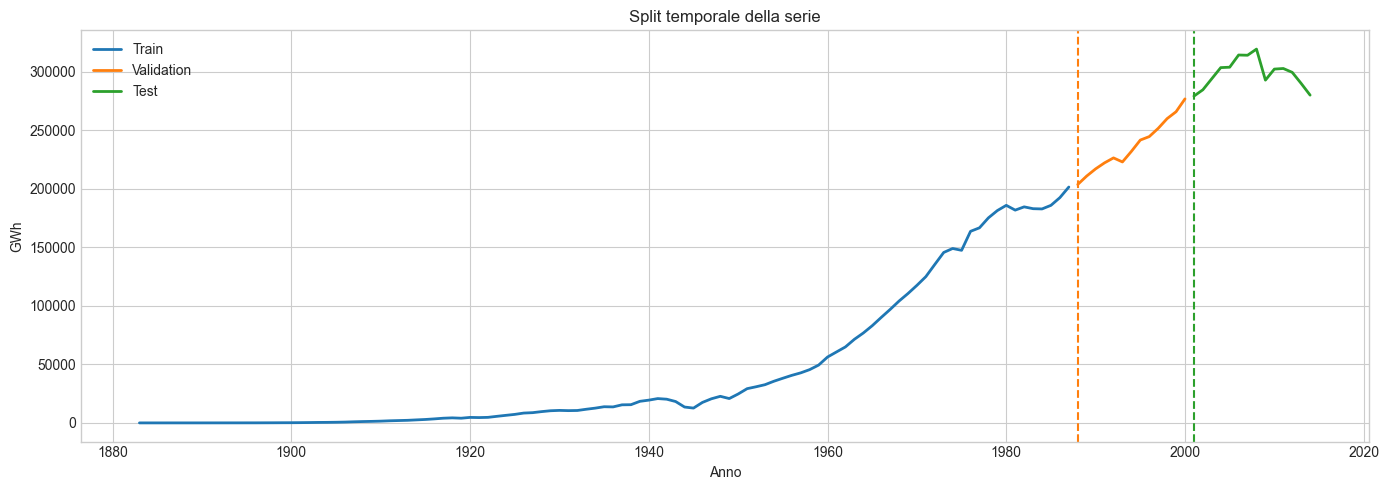

In [57]:
fig_step3_split = plot_split(train_series, val_series, test_series)
fig_step3_split

Commento operativo Step 3: split cronologico senza shuffle (train/val/test).

## Step 4 - Modello statistico

In [58]:
log_orders = [(0, 0, 1), (1, 0, 0), (1, 0, 1), (2, 0, 1)]
d2_orders = [(0, 2, 1), (1, 2, 0), (1, 2, 1), (2, 2, 1)]

In [59]:
step4_results = compare_logd0_vs_leveld2(
    train_series,
    val_series,
    log_orders=log_orders,
    d2_orders=d2_orders,
)
step4_results

c:\Users\giann\Documents\GitHub\FinalProject\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\giann\Documents\GitHub\FinalProject\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,family,order,aic,val_mae,val_rmse,val_mape
0,level_d2,"(2, 2, 1)",1910.586278,3645.130292,5258.275725,1.470633
1,level_d2,"(0, 2, 1)",1906.876953,4721.619383,6357.691915,1.886933
2,level_d2,"(1, 2, 1)",1908.713184,4716.108298,6394.732048,1.883213
3,level_d2,"(1, 2, 0)",1921.809023,22394.976117,24677.672123,9.198242
4,log_d0,"(1, 0, 1)",-92.098071,37242.943846,44441.907040,14.962038
5,log_d0,"(1, 0, 0)",-48.877517,38809.998044,45317.347163,15.662197
6,log_d0,"(2, 0, 1)",-145.549178,63281.386272,76574.299501,25.359089
7,log_d0,"(0, 0, 1)",410.550091,229332.440335,230697.935373,96.852420


In [60]:
step4_selected = select_and_forecast(
    train_series,
    val_series,
    test_series,
    step4_results,
)

print(
    f"Best family/model on validation: "
    f"{step4_selected['best_family']} ARIMA{step4_selected['best_order']}"
 )

pd.DataFrame(
    [
        {"split": "validation", **step4_selected["val_metrics"]},
        {"split": "test", **step4_selected["test_metrics"]},
    ]
)

Best family/model on validation: level_d2 ARIMA(2, 2, 1)


c:\Users\giann\Documents\GitHub\FinalProject\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,split,mae,rmse,mape
0,validation,3645.130292,5258.275725,1.470633
1,test,32166.431677,44758.230587,10.946405


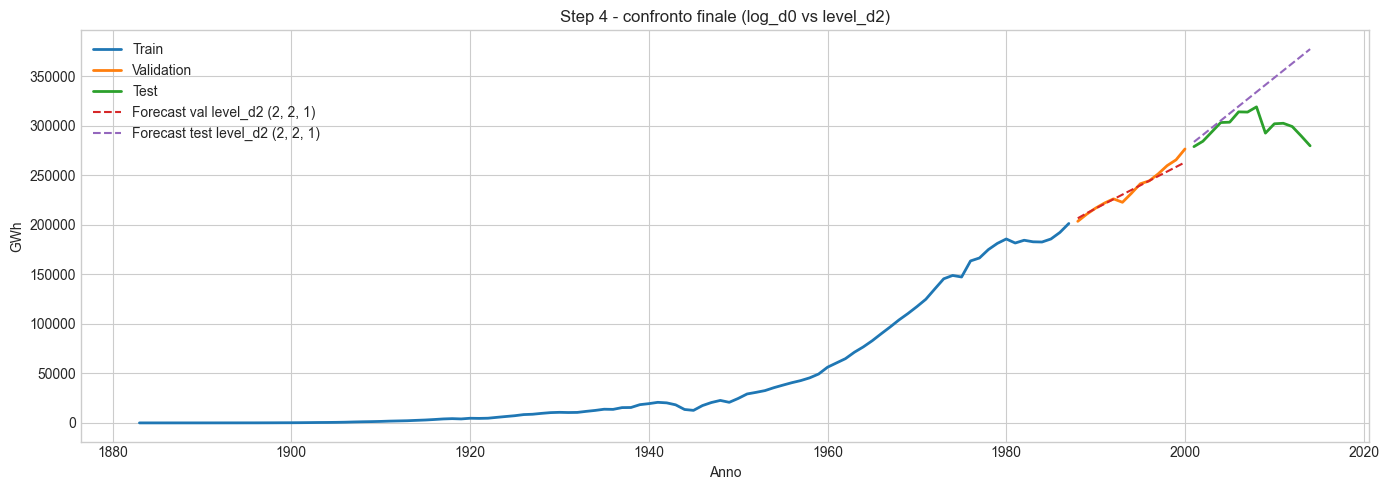

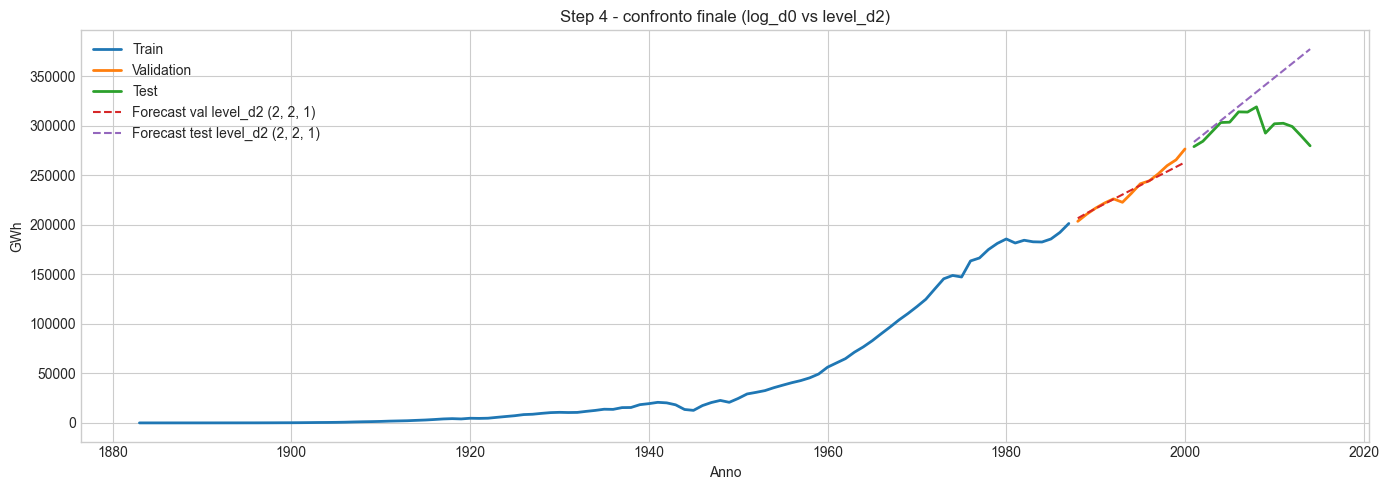

In [61]:
fig_step4_forecast = plot_forecast(
    train_series,
    val_series,
    test_series,
    step4_selected["val_pred"],
    step4_selected["test_pred"],
    step4_selected["best_family"],
    step4_selected["best_order"],
)
fig_step4_forecast

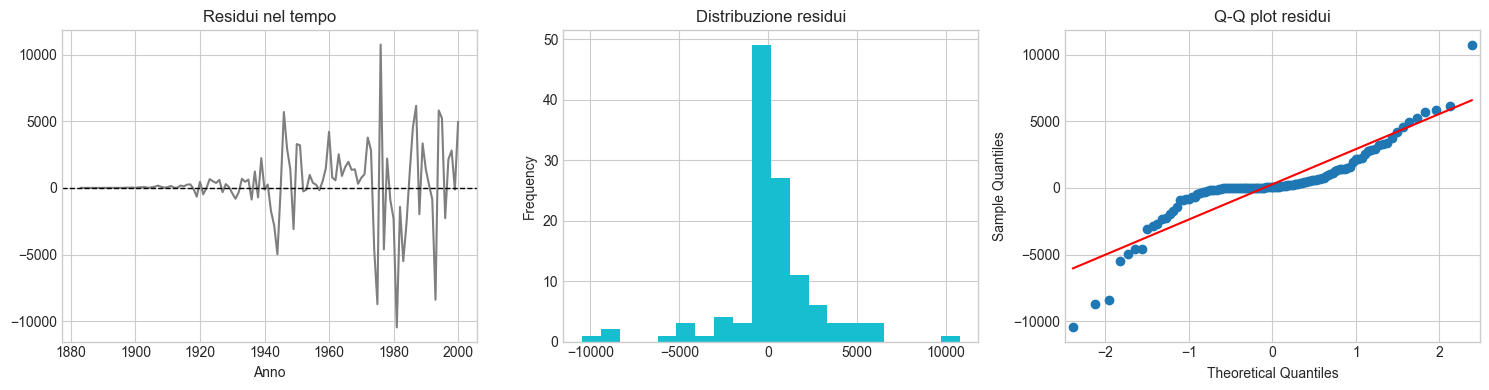

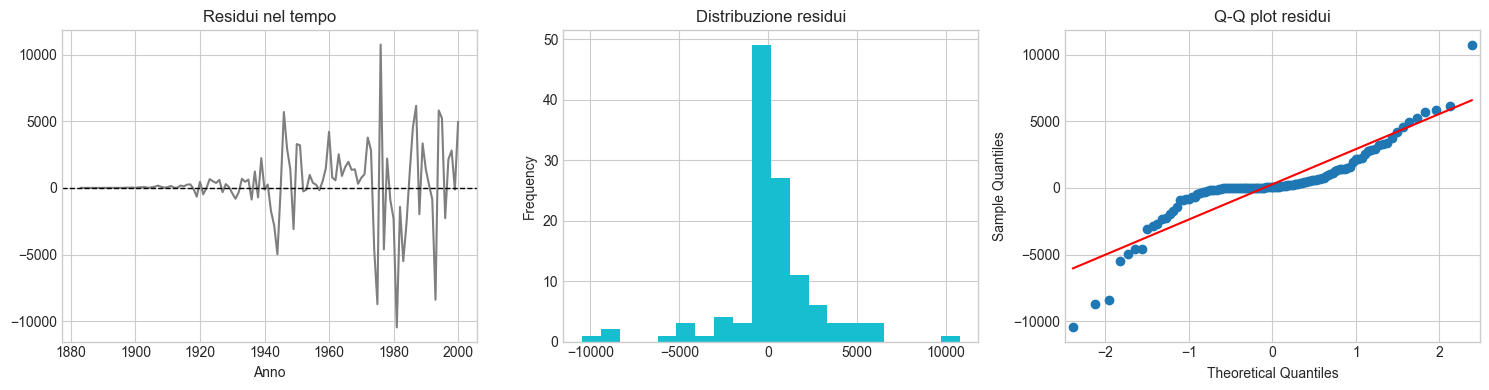

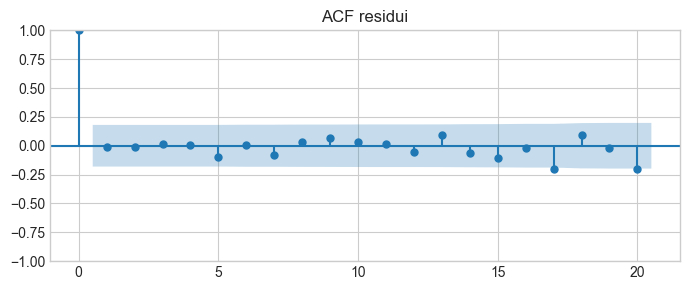

In [62]:
fig_step4_residuals_1, fig_step4_residuals_2 = plot_residual_diagnostics(
    step4_selected["residuals"],
)
fig_step4_residuals_1

Commento operativo Step 4: selezione su validation, verifica finale su test e residui.